## Modelo SARIMA univariado para Consumption

Se ajusta un modelo SARIMA estacional sobre la serie horaria `Consumption`, sin regresores exógenos. La estacionalidad configurada es diaria (`24` observaciones por ciclo). La evaluacion respeta el orden temporal: se pronostica validation desde train y luego test desde train + validation.

In [1]:
# Librerias para los modelos SARIMA univariados
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from ml_course.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


## Estimacion y evaluacion

Se usa el modelo `SARIMA(1, 1, 1) x (1, 1, 1, 24)` con `Consumption` como unica variable. Los bloques de validation y test se pronostican desde un origen fijo; al ser horizontes largos, las metricas resumen el error acumulado y no solo el ajuste de corto plazo.

In [6]:
# Modelo SARIMA univariado: solo se utiliza Consumption, sin regresores
TARGET = 'Consumption'
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 24)

# Consolidamos timestamps duplicados y completamos la frecuencia horaria
hourly_series = (
    raw[TARGET]
    .sort_index()
    .groupby(level=0)
    .mean()
    .asfreq('h')
    .interpolate(method='time')
    .ffill()
    .bfill()
)

n_rows = len(hourly_series)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_endog = hourly_series.iloc[:train_end]
val_endog = hourly_series.iloc[train_end:val_end]
test_endog = hourly_series.iloc[val_end:]

# Ajuste con train y pronostico del bloque de validacion
sarima_validation = SARIMAX(
    train_endog,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=100)

pred_val_sarima = pd.Series(
    sarima_validation.get_forecast(steps=len(val_endog)).predicted_mean.to_numpy(),
    index=val_endog.index,
    name='SARIMA',
)

# Reajuste con train + validation y pronostico del bloque de test
train_val_endog = pd.concat([train_endog, val_endog])
sarima_final = SARIMAX(
    train_val_endog,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=100)

pred_test_sarima = pd.Series(
    sarima_final.get_forecast(steps=len(test_endog)).predicted_mean.to_numpy(),
    index=test_endog.index,
    name='SARIMA',
)

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

sarima_results = pd.DataFrame([
    {
        'split': 'validation',
        'MAE': mean_absolute_error(val_endog, pred_val_sarima),
        'RMSE': np.sqrt(mean_squared_error(val_endog, pred_val_sarima)),
        'R2': r2_score(val_endog, pred_val_sarima),
        'MAPE_%': mape(val_endog, pred_val_sarima),
    },
    {
        'split': 'test',
        'MAE': mean_absolute_error(test_endog, pred_test_sarima),
        'RMSE': np.sqrt(mean_squared_error(test_endog, pred_test_sarima)),
        'R2': r2_score(test_endog, pred_test_sarima),
        'MAPE_%': mape(test_endog, pred_test_sarima),
    },
]).set_index('split')

print('Variable objetivo:', TARGET)
print('Regresores: ninguno (SARIMA univariado)')
print('Orden SARIMA:', order)
print('Orden estacional:', seasonal_order)
print('\nMetricas del modelo SARIMA:')
display(sarima_results.round(4))

Variable objetivo: Consumption
Regresores: ninguno (SARIMA univariado)
Orden SARIMA: (1, 1, 1)
Orden estacional: (1, 1, 1, 24)

Metricas del modelo SARIMA:


,MAE,RMSE,R2,MAPE_%
split,,,,
validation,12410.382,14012.4421,-197.1229,203.4370
test,10062.274,11189.6237,-104.1274,166.0229


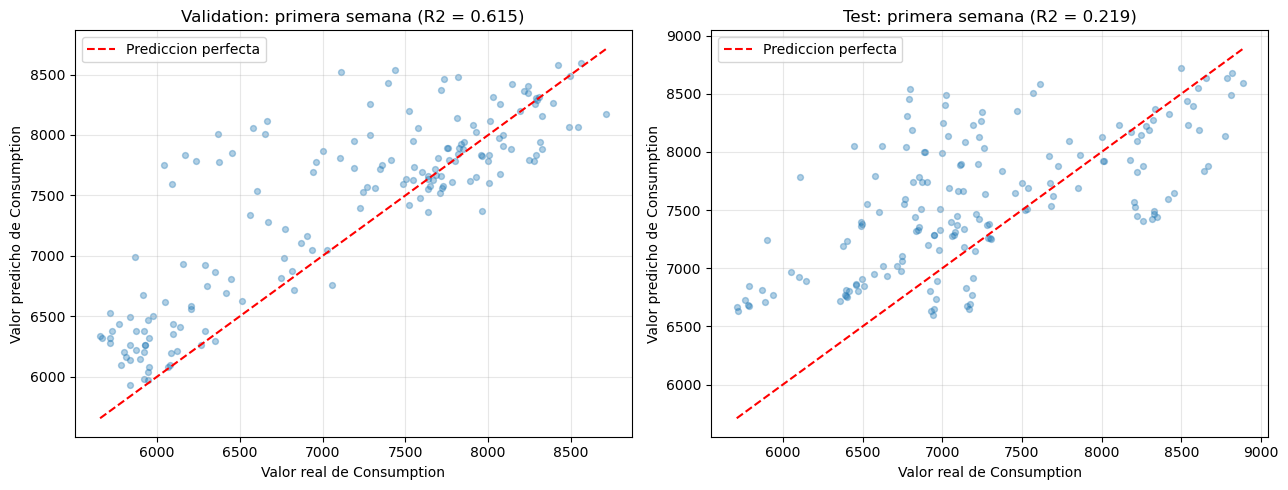

In [9]:
# Comparacion real vs. predicho para la primera semana de cada particion
hours_in_week = 24 * 7
scatter_sets = [
    ('Validation', val_endog.iloc[:hours_in_week], pred_val_sarima.iloc[:hours_in_week]),
    ('Test', test_endog.iloc[:hours_in_week], pred_test_sarima.iloc[:hours_in_week]),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (split_name, actual, predicted) in zip(axes, scatter_sets):
    score = r2_score(actual, predicted)
    ax.scatter(actual, predicted, alpha=0.35, s=18)
    lower_bound = min(actual.min(), predicted.min())
    upper_bound = max(actual.max(), predicted.max())
    ax.plot(
        [lower_bound, upper_bound],
        [lower_bound, upper_bound],
        color='red',
        linestyle='--',
        label='Prediccion perfecta',
    )
    ax.set_title(f'{split_name}: primera semana (R2 = {score:.3f})')
    ax.set_xlabel('Valor real de Consumption')
    ax.set_ylabel('Valor predicho de Consumption')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

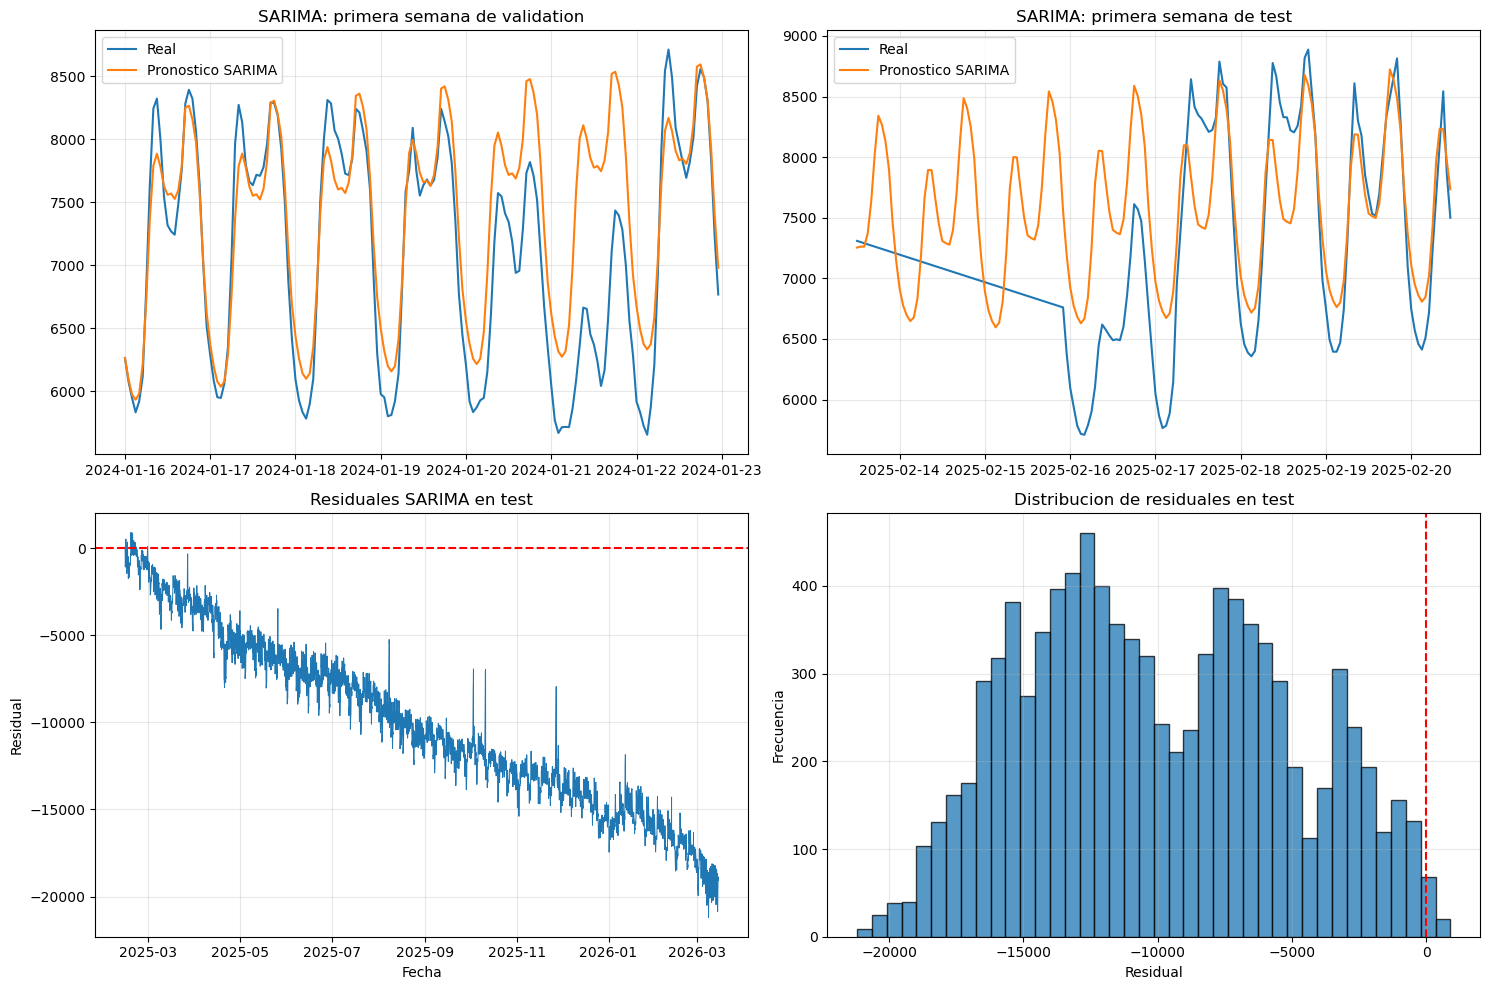

In [7]:
# Diagnostico visual del modelo SARIMA univariado
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

validation_window = min(24 * 7, len(val_endog))
test_window = min(24 * 7, len(test_endog))
axes[0, 0].plot(val_endog.index[:validation_window], val_endog.iloc[:validation_window], label='Real')
axes[0, 0].plot(pred_val_sarima.index[:validation_window], pred_val_sarima.iloc[:validation_window], label='Pronostico SARIMA')
axes[0, 0].set_title('SARIMA: primera semana de validation')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(test_endog.index[:test_window], test_endog.iloc[:test_window], label='Real')
axes[0, 1].plot(pred_test_sarima.index[:test_window], pred_test_sarima.iloc[:test_window], label='Pronostico SARIMA')
axes[0, 1].set_title('SARIMA: primera semana de test')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

test_residuals_sarima = test_endog.to_numpy() - pred_test_sarima.to_numpy()
axes[1, 0].plot(test_endog.index, test_residuals_sarima, linewidth=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Residuales SARIMA en test')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(test_residuals_sarima, bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('Distribucion de residuales en test')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Auto-SARIMA

`auto_arima` selecciona los órdenes no estacionales y estacionales por AIC, usando exclusivamente `Consumption` y la partición train. Las órdenes se acotan para mantener la búsqueda manejable. El modelo se actualiza con validation antes de pronosticar test.

In [4]:
# Auto-SARIMA univariado: seleccionar ordenes y evaluar validation/test
TARGET = 'Consumption'
auto_hourly_series = (
    raw[TARGET]
    .sort_index()
    .groupby(level=0)
    .mean()
    .asfreq('h')
    .interpolate(method='time')
    .ffill()
    .bfill()
)

auto_n_rows = len(auto_hourly_series)
auto_train_end = int(auto_n_rows * 0.70)
auto_val_end = int(auto_n_rows * 0.85)
auto_train = auto_hourly_series.iloc[:auto_train_end]
auto_validation = auto_hourly_series.iloc[auto_train_end:auto_val_end]
auto_test = auto_hourly_series.iloc[auto_val_end:]

# Buscar ordenes sobre los ultimos 90 dias de train y ajustar con todo train
auto_search_window = min(24 * 90, len(auto_train))
auto_search_series = auto_train.iloc[-auto_search_window:]
auto_order_search = auto_arima(
    auto_search_series,
    seasonal=True,
    m=24,
    start_p=0,
    max_p=4,
    start_q=0,
    max_q=4,
    start_P=0,
    max_P=2,
    start_Q=0,
    max_Q=4,
    max_order=4,
    information_criterion='aic',
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    maxiter=50,
    n_jobs=1,
)

auto_order = auto_order_search.order
auto_seasonal_order = auto_order_search.seasonal_order
auto_sarima_validation = SARIMAX(
    auto_train,
    order=auto_order,
    seasonal_order=auto_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=100)

pred_val_auto_sarima = pd.Series(
    auto_sarima_validation.get_forecast(steps=len(auto_validation)).predicted_mean.to_numpy(),
    index=auto_validation.index,
    name='Auto-SARIMA',
)

# Incorporar validation observada antes de generar el pronostico de test
auto_sarima_test = auto_sarima_validation.append(auto_validation, refit=False)
pred_test_auto_sarima = pd.Series(
    auto_sarima_test.get_forecast(steps=len(auto_test)).predicted_mean.to_numpy(),
    index=auto_test.index,
    name='Auto-SARIMA',
)

def auto_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

auto_sarima_results = pd.DataFrame([
    {
        'split': 'validation',
        'MAE': mean_absolute_error(auto_validation, pred_val_auto_sarima),
        'RMSE': np.sqrt(mean_squared_error(auto_validation, pred_val_auto_sarima)),
        'R2': r2_score(auto_validation, pred_val_auto_sarima),
        'MAPE_%': auto_mape(auto_validation, pred_val_auto_sarima),
    },
    {
        'split': 'test',
        'MAE': mean_absolute_error(auto_test, pred_test_auto_sarima),
        'RMSE': np.sqrt(mean_squared_error(auto_test, pred_test_auto_sarima)),
        'R2': r2_score(auto_test, pred_test_auto_sarima),
        'MAPE_%': auto_mape(auto_test, pred_test_auto_sarima),
    },
]).set_index('split')

print('Orden no estacional seleccionado:', auto_order)
print('Orden estacional seleccionado:', auto_seasonal_order)
print('Regresores: ninguno')
display(auto_sarima_results.round(4))

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=30663.594, Time=0.11 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=4.13 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=28278.398, Time=3.18 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=30661.599, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[24] intercept   : AIC=29276.422, Time=0.46 sec
 ARIMA(0,1,1)(1,0,1)[24] intercept   : AIC=inf, Time=7.67 sec
 ARIMA(0,1,1)(0,0,2)[24] intercept   : AIC=27871.416, Time=23.13 sec
 ARIMA(0,1,1)(1,0,2)[24] intercept   : AIC=inf, Time=52.15 sec
 ARIMA(0,1,1)(0,0,3)[24] intercept   : AIC=27571.067, Time=48.17 sec
 ARIMA(0,1,1)(1,0,3)[24] intercept   : AIC=inf, Time=129.10 sec
 ARIMA(0,1,1)(0,0,4)[24] intercept   : AIC=inf, Time=102.41 sec
 ARIMA(0,1,1)(1,0,4)[24] intercept   : AIC=inf, Time=217.64 sec
 ARIMA(0,1,0)(0,0,3)[24] intercept   : AIC=inf, Time=47.99 sec
 ARIMA(1,1,1)(0,0,3)[24] intercept   : AIC=27287.811, Time=42.56 sec
 ARIMA(1,1,1)(0,0,2)[24] intercept  

MemoryError: Unable to allocate 158. MiB for an array with shape (98, 98, 2160) and data type float64

In [ ]:
# ACF y PACF de la serie de entrenamiento y sus diferencias
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

acf_train = auto_train.astype(float)
regular_diff_train = acf_train.diff().dropna()
seasonal_diff_train = acf_train.diff(24).dropna()
max_lags = 72

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_acf(regular_diff_train, lags=max_lags, ax=axes[0, 0], zero=False)
axes[0, 0].set_title('ACF: primera diferencia (d=1)')
plot_pacf(regular_diff_train, lags=max_lags, ax=axes[0, 1], zero=False, method='ywm')
axes[0, 1].set_title('PACF: primera diferencia (d=1)')
plot_acf(seasonal_diff_train, lags=max_lags, ax=axes[1, 0], zero=False)
axes[1, 0].set_title('ACF: diferencia estacional (D=1, m=24)')
plot_pacf(seasonal_diff_train, lags=max_lags, ax=axes[1, 1], zero=False, method='ywm')
axes[1, 1].set_title('PACF: diferencia estacional (D=1, m=24)')

for ax in axes.flat:
    ax.set_xlabel('Rezago (horas)')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Correlaciones en rezagos cortos y multiplos del ciclo diario
regular_acf_values = acf(regular_diff_train, nlags=max_lags, fft=True)
regular_pacf_values = pacf(regular_diff_train, nlags=max_lags, method='ywm')
seasonal_acf_values = acf(seasonal_diff_train, nlags=max_lags, fft=True)
seasonal_pacf_values = pacf(seasonal_diff_train, nlags=max_lags, method='ywm')

selected_lags = list(range(1, 8)) + [24, 48, 72]
acf_pacf_summary = pd.DataFrame({
    'lag': selected_lags,
    'ACF_d1': [regular_acf_values[lag] for lag in selected_lags],
    'PACF_d1': [regular_pacf_values[lag] for lag in selected_lags],
    'ACF_D1_m24': [seasonal_acf_values[lag] for lag in selected_lags],
    'PACF_D1_m24': [seasonal_pacf_values[lag] for lag in selected_lags],
})
confidence_limit = 1.96 / np.sqrt(len(regular_diff_train))
print(f'Limite aproximado de significancia al 95%: +/-{confidence_limit:.4f}')
display(acf_pacf_summary.round(4))